# 2D Upper body interpersonal dynamics - MOSAIC

In [80]:
import json
import random
from pathlib import Path

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
import notebook_utils as nb_utils  # noqa: F401

# Define the root path of the project to locate artifacts
ROOT = Path.cwd().parents[1]
ingest_dir = ROOT / "artifacts" / "ingest" / "mosaic"
pose_path = ingest_dir / "pose.parquet"
# Load the ingested data from the Parquet file
df = pd.read_parquet(pose_path)

## Ingest
First we will verify that the ingest step worked as expected. We will print the number of "trials" (csvs) ingested and also plot the keypoints. Each time you rerun the cell a new random frame is plotted.

Found 12 trials in the ingested data.


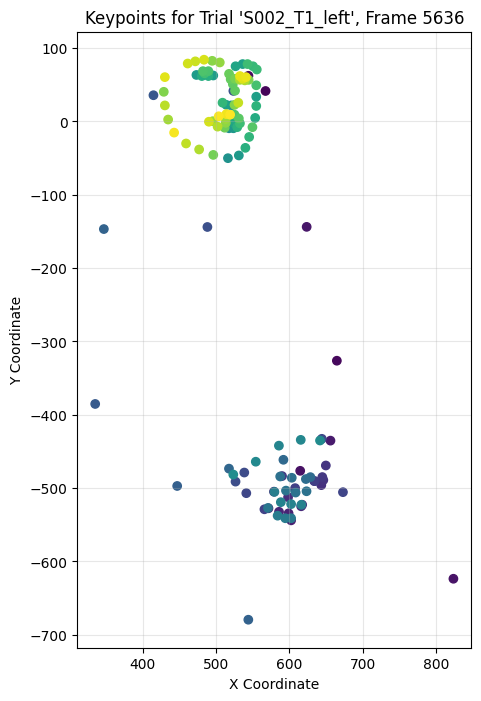

In [81]:
# Print number of trials
n_trials = df["trial_id"].nunique()
print(f"Found {n_trials} trials in the ingested data.")

# Create a figure of keypoints from a random frame in the first trial
trial_ids = df["trial_id"].unique()
selected_trial_id = trial_ids[0]
trial_df = df[df["trial_id"] == selected_trial_id].copy()
frame_ids = trial_df["frame"].unique()
random_frame_id = random.choice(frame_ids)
frame_df = trial_df[trial_df["frame"] == random_frame_id]
fig, ax = plt.subplots(figsize=(8, 8))
colors = cm.viridis(np.linspace(0, 1, len(frame_df)))
ax.scatter(frame_df["x"], frame_df["y"], c=colors)
ax.set_title(f"Keypoints for Trial '{selected_trial_id}', Frame {random_frame_id}")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)

plt.show()

## Preprocessing

### Extract a Subset of Keypoints
Instead of preprocessing all 70 keypoints from openpose we will select relevant ones that are used in the downstream analysis. Specifically we will focus on three regions of interest (ROI): centre face, upper body, and arms.

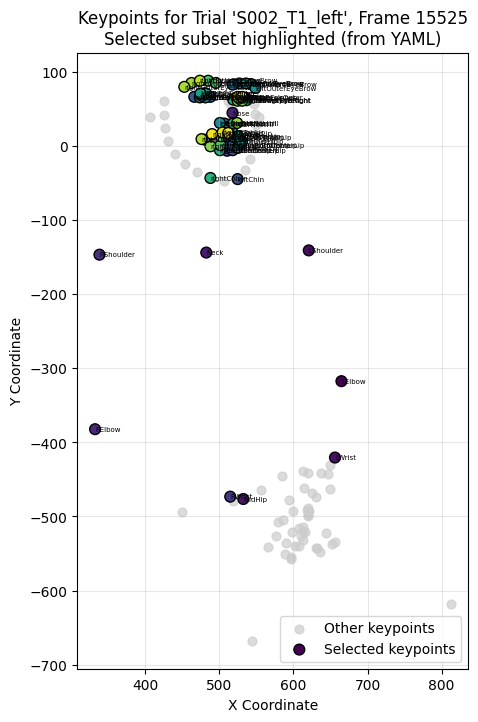

In [82]:
# Load keypoints from preprocess.yaml
cfg_path = ROOT / "examples" / "case_study_2_mosaic" / "configs" / "preprocess.yaml"
with open(cfg_path, "r") as f:
    cfg = yaml.safe_load(f)
selected_keypoints = cfg["preprocess"]["selection"]["keypoints"]

# Use the same trial and random frame as before
trial_ids = df["trial_id"].unique()
selected_trial_id = trial_ids[0]
trial_df = df[df["trial_id"] == selected_trial_id].copy()
frame_ids = trial_df["frame"].unique()
random_frame_id = random.choice(frame_ids)
frame_df = trial_df[trial_df["frame"] == random_frame_id]

# Split into selected and non-selected keypoints
selected_mask = frame_df["keypoint"].isin(selected_keypoints)
selected_df = frame_df[selected_mask]
other_df = frame_df[~selected_mask]

fig, ax = plt.subplots(figsize=(8, 8))
if not other_df.empty:
    ax.scatter(
        other_df["x"],
        other_df["y"],
        c="#cccccc",
        s=40,
        label="Other keypoints",
        alpha=0.7,
    )
if not selected_df.empty:
    colors = cm.viridis(np.linspace(0, 1, len(selected_df)))
    ax.scatter(
        selected_df["x"],
        selected_df["y"],
        c=colors,
        s=60,
        label="Selected keypoints",
        edgecolor="k",
    )

for idx, row in selected_df.iterrows():
    ax.text(
        row["x"],
        row["y"],
        str(row["keypoint"]),
        fontsize=5,
        color="black",
        ha="left",
        va="center",
    )

ax.set_title(
    f"Keypoints for Trial '{selected_trial_id}', Frame {random_frame_id}\nSelected subset highlighted (from YAML)"
)
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()

### Window & Interpolation
The next step is to define window lengths and perform quality control. For this dataset we used windows of 60 seconds with 50% overlap. The max interpolation was set to 1 second. This means if the confidence was below the threshold (0.30) for more than 1 second the window was excluded. We will also print how many total frames were interpolated

In [83]:
# Load QC and provenance artifacts
preprocess_dir = ROOT / "artifacts" / "preprocess" / "mosaic"
qc_path = preprocess_dir / "qc_preprocess.json"
prov_path = preprocess_dir / "provenance.json"

with open(qc_path, "r") as f:
    qc_data = json.load(f)

with open(prov_path, "r") as f:
    prov_data = json.load(f)

# Extract parameters from the config within the provenance file
cfg = prov_data["config"]
conf_min = cfg["confidence"]["conf_min"]
max_gap_frames = cfg["missing"]["interpolation"]["limit"]["max_gap_frames"]
window_length = cfg["windowing"]["length_s"]
window_step = cfg["windowing"]["step_s"]
n_dropped = qc_data["summary"]["n_dropped"]

# Calculate interpolated frames
# 1. Load the raw data and apply selection/confidence filters to get pre-interpolation state
pre_df = pd.read_parquet(pose_path)
pre_df = pre_df[pre_df["keypoint"].isin(selected_keypoints)]
pre_df = pre_df[pre_df["conf"] >= conf_min]
nans_before = pre_df[["x", "y"]].isna().sum().sum()

# 2. Load the cleaned data (which has been interpolated)
clean_df = pd.read_parquet(preprocess_dir / "pose_clean.parquet")
nans_after = clean_df[["x", "y"]].isna().sum().sum()

# 3. The number of interpolated values is the reduction in NaNs
total_interpolated = nans_before - nans_after

print("--- Preprocessing Parameters ---")
print(f"Confidence Threshold: {conf_min}")
print(f"Max Interpolation Gap: {max_gap_frames} frames")
print(f"Window Length: {window_length} seconds")
print(f"Window Step: {window_step} seconds")
print("--- QC Results ---")
print(f"Number of Windows Dropped: {n_dropped}")
print(f"Total Interpolated Values (x, y): {total_interpolated:,}")

--- Preprocessing Parameters ---
Confidence Threshold: 0.3
Max Interpolation Gap: 60 frames
Window Length: 60.0 seconds
Window Step: 30.0 seconds
--- QC Results ---
Number of Windows Dropped: 2
Total Interpolated Values (x, y): -6,058


### Butterworth Filter

--- Filter Configuration ---
Lowpass Filter: Enabled
Cutoff Frequency: 10.0 Hz
Order: 4


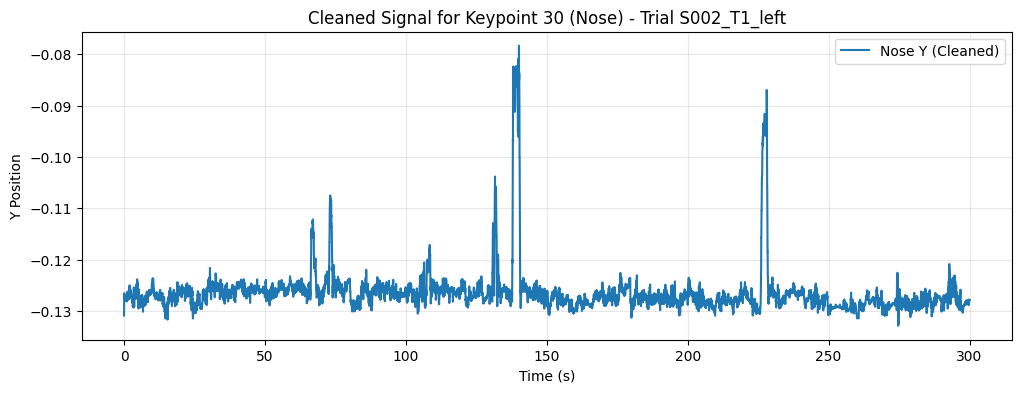

In [84]:
# Extract filter settings from provenance
filter_cfg = prov_data["config"]["detrend_filter"]
print("--- Filter Configuration ---")
if filter_cfg["lowpass"]["enabled"]:
    print("Lowpass Filter: Enabled")
    print(f"Cutoff Frequency: {filter_cfg['lowpass']['cutoff_hz']} Hz")
    print(f"Order: {filter_cfg['lowpass']['order']}")
else:
    print("Lowpass Filter: Disabled")

# Plot a sample of the cleaned (filtered & aligned) signal
# using the clean_df loaded in the previous step
trial_clean = clean_df[clean_df["trial_id"] == selected_trial_id]
kp_clean = trial_clean[trial_clean["keypoint"] == "Nose"]  # Nose tip

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(kp_clean["time"], kp_clean["y"], label="Nose Y (Cleaned)")
ax.set_title(f"Cleaned Signal for Keypoint 30 (Nose) - Trial {selected_trial_id}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Y Position")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### Procrustes Transformation

Loaded alignment transforms for 12 trials.


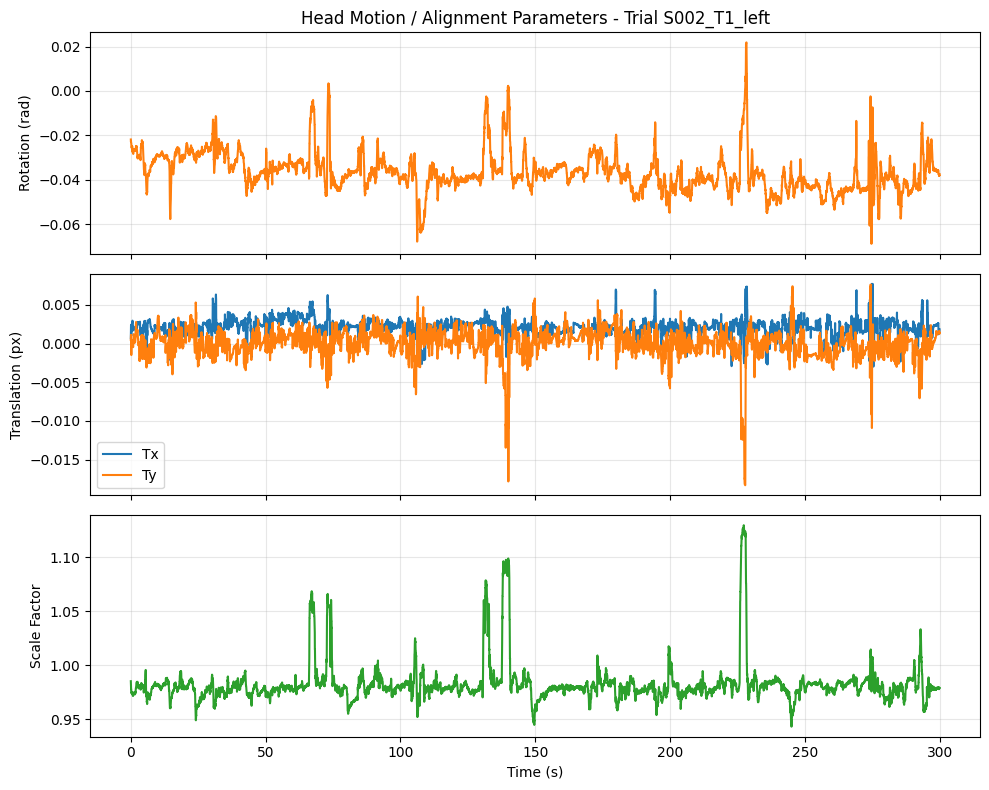

In [85]:
# Load alignment transforms
transforms_path = preprocess_dir / "alignment_transforms.parquet"
transforms_df = pd.read_parquet(transforms_path)

# Filter for the selected trial
trial_transforms = transforms_df[
    transforms_df["trial_id"] == selected_trial_id
].sort_values("time")

print(
    f"Loaded alignment transforms for {len(transforms_df['trial_id'].unique())} trials."
)

# Plot head motion parameters
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Rotation
axes[0].plot(
    trial_transforms["time"], trial_transforms["rotation_angle"], color="tab:orange"
)
axes[0].set_ylabel("Rotation (rad)")
axes[0].set_title(f"Head Motion / Alignment Parameters - Trial {selected_trial_id}")
axes[0].grid(True, alpha=0.3)

# Translation
axes[1].plot(trial_transforms["time"], trial_transforms["translation_x"], label="Tx")
axes[1].plot(trial_transforms["time"], trial_transforms["translation_y"], label="Ty")
axes[1].set_ylabel("Translation (px)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Scale
axes[2].plot(trial_transforms["time"], trial_transforms["scale"], color="tab:green")
axes[2].set_ylabel("Scale Factor")
axes[2].set_xlabel("Time (s)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Linear Analysis / Features

### Compute derived signals

For each frame, keypoints belonging to the ROIs were spatially aggregated by computing the centroid (i.e., the mean x- and y-coordinates). Velocity (the first-order temporal derivative) was then computed from these centroid trajectories, and the magnitude of the resulting velocity vector was retained as a one-dimensional time series representing regional, sign-invariant movement intensity. 

For each ROI, we then extracted linear amplitude-based metrics from the magnitude time series on a window-by-window basis. These included root-mean-square (RMS) movement magnitude, as well as the mean and standard deviation of velocity magnitude.

We will save summary statistics for these features in each window.

### ROI Time Series for CRQA

The ROI centroid velocity magnitude time series is saved separately (`roi_series.parquet`) for use in cross-recurrence analysis. Let's visualize these time series for a pair of participants.

In [86]:
# Load ROI time series used for CRQA
roi_series_path = ROOT / "artifacts" / "features" / "mosaic" / "roi_series.parquet"
roi_series_df = pd.read_parquet(roi_series_path)

print(f"ROI series shape: {roi_series_df.shape}")
print(f"Columns: {roi_series_df.columns.tolist()}")
print(f"Trials: {roi_series_df['trial_id'].unique().tolist()}")

ROI series shape: (140382, 11)
Columns: ['time', 'centre_face_vel_mag', 'centre_face_vel_x', 'centre_face_vel_y', 'upper_body_vel_mag', 'upper_body_vel_x', 'upper_body_vel_y', 'arms_vel_mag', 'arms_vel_x', 'arms_vel_y', 'trial_id']
Trials: ['S002_T1_left', 'S002_T1_right', 'S002_T2_left', 'S002_T2_right', 'S002_T3_left', 'S002_T3_right', 'S002_T4_left', 'S002_T4_right', 'S002_T5_left', 'S002_T5_right', 'S002_T6_left', 'S002_T6_right']


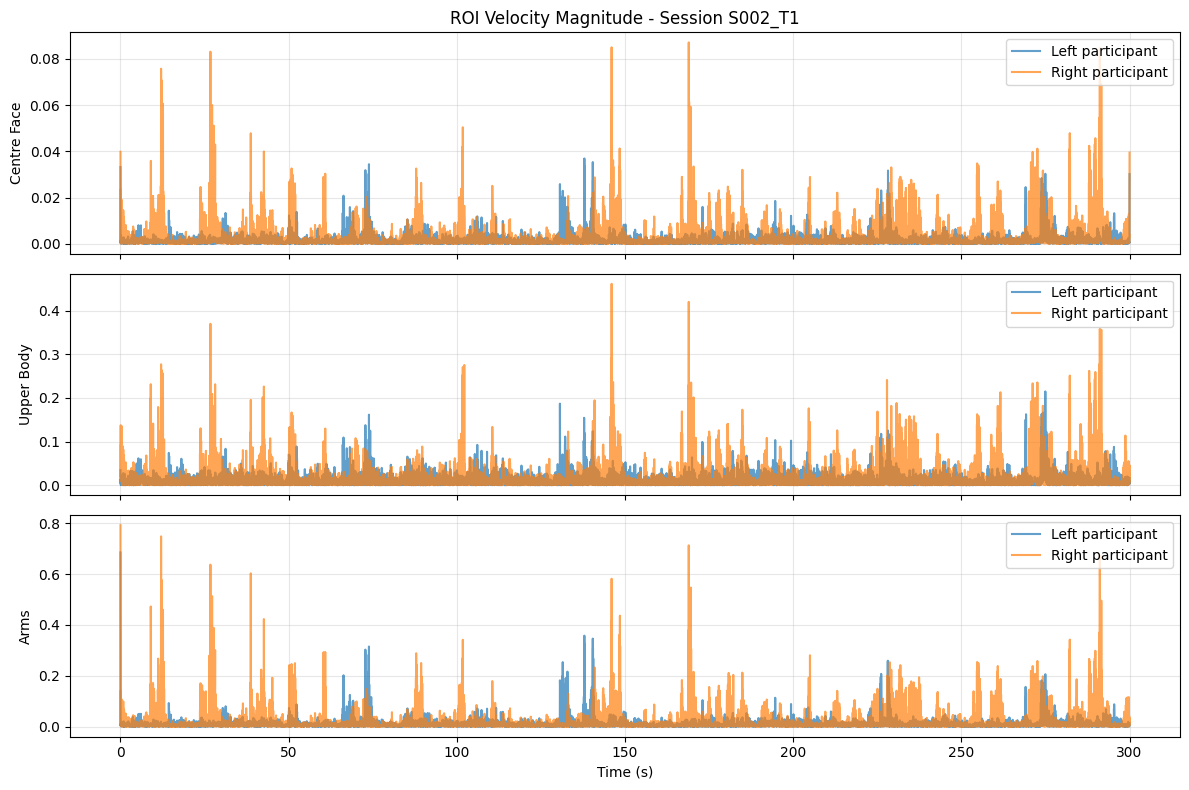

In [87]:
# Plot ROI velocity magnitude for a paired session (left vs right participant)
# Find a session with both left and right participants
trial_ids = roi_series_df["trial_id"].unique()
base_sessions = set()
for tid in trial_ids:
    if tid.endswith("_left"):
        base = tid[:-5]
        if f"{base}_right" in trial_ids:
            base_sessions.add(base)

if base_sessions:
    session = sorted(base_sessions)[0]
    left_df = roi_series_df[roi_series_df["trial_id"] == f"{session}_left"]
    right_df = roi_series_df[roi_series_df["trial_id"] == f"{session}_right"]
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    
    for ax, roi in zip(axes, ["centre_face_vel_mag", "upper_body_vel_mag", "arms_vel_mag"]):
        ax.plot(left_df["time"], left_df[roi], label="Left participant", alpha=0.7)
        ax.plot(right_df["time"], right_df[roi], label="Right participant", alpha=0.7)
        ax.set_ylabel(roi.replace("_vel_mag", "").replace("_", " ").title())
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)
    
    axes[0].set_title(f"ROI Velocity Magnitude - Session {session}")
    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()
else:
    print("No paired sessions found.")

In [88]:
# Load extracted features (summary statistics per window)
features_dir = ROOT / "artifacts" / "features" / "mosaic"
features_path = features_dir / "features.parquet"

# Load feature config to see what was extracted
feat_prov_path = features_dir / "provenance_features.json"
with open(feat_prov_path, "r") as f:
    feat_prov = json.load(f)

cfg = feat_prov.get("config", {})
roi_cfg = cfg.get("roi", {})

print("=== ROI Feature Extraction ===")
print(f"Enabled: {roi_cfg.get('enabled', False)}")
print(f"Derivatives: {roi_cfg.get('derivatives', [])}")
print(f"Stats: {roi_cfg.get('stats', [])}")

regions = roi_cfg.get("regions", [])
print(f"\nRegions of Interest ({len(regions)}):")
for r in regions:
    print(f"  - {r.get('name')}: {len(r.get('keypoints', []))} keypoints")

# Load and display features
features_df = pd.read_parquet(features_path)
print(f"\nLoaded {len(features_df)} feature rows across {features_df['trial_id'].nunique()} trials")

# Show ROI-specific features
roi_features = features_df[features_df["keypoint"].str.contains("centre_face|upper_body|arms", na=False)]
print(f"\nROI Features: {roi_features['feature'].unique().tolist()}")

=== ROI Feature Extraction ===
Enabled: True
Derivatives: ['velocity']
Stats: ['mean', 'rms']

Regions of Interest (3):
  - centre_face: 54 keypoints
  - upper_body: 4 keypoints
  - arms: 6 keypoints

Loaded 216 feature rows across 12 trials

ROI Features: ['centre_face_vel_mag_mean', 'centre_face_vel_mag_rms', 'centre_face_vel_x_mean', 'centre_face_vel_x_rms', 'centre_face_vel_y_mean', 'centre_face_vel_y_rms', 'upper_body_vel_mag_mean', 'upper_body_vel_mag_rms', 'upper_body_vel_x_mean', 'upper_body_vel_x_rms', 'upper_body_vel_y_mean', 'upper_body_vel_y_rms', 'arms_vel_mag_mean', 'arms_vel_mag_rms', 'arms_vel_x_mean', 'arms_vel_x_rms', 'arms_vel_y_mean', 'arms_vel_y_rms']


### Stats/Figures

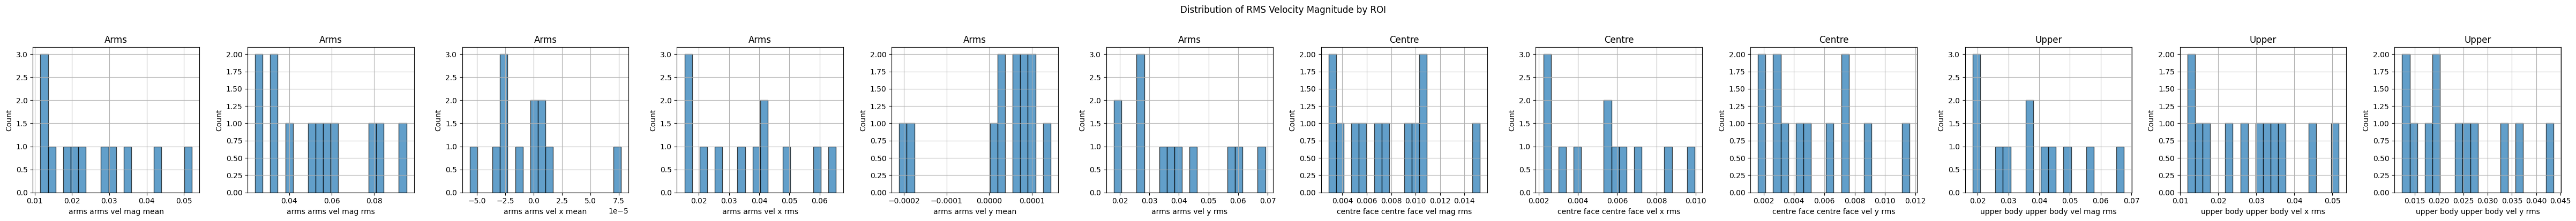

Feature columns: ['arms_arms_vel_mag_mean', 'arms_arms_vel_mag_rms', 'arms_arms_vel_x_mean', 'arms_arms_vel_x_rms', 'arms_arms_vel_y_mean', 'arms_arms_vel_y_rms', 'centre_face_centre_face_vel_mag_mean', 'centre_face_centre_face_vel_mag_rms', 'centre_face_centre_face_vel_x_mean', 'centre_face_centre_face_vel_x_rms', 'centre_face_centre_face_vel_y_mean', 'centre_face_centre_face_vel_y_rms', 'upper_body_upper_body_vel_mag_mean', 'upper_body_upper_body_vel_mag_rms', 'upper_body_upper_body_vel_x_mean', 'upper_body_upper_body_vel_x_rms', 'upper_body_upper_body_vel_y_mean', 'upper_body_upper_body_vel_y_rms']


In [89]:
# Visualize ROI summary statistics across windows
# Pivot to wide format for easier plotting
roi_wide = features_df[features_df["keypoint"].str.contains("centre_face|upper_body|arms", na=False)].copy()

if not roi_wide.empty:
    # Create feature column name
    roi_wide["col_name"] = roi_wide["keypoint"] + "_" + roi_wide["feature"]
    
    # Pivot
    pivot_df = roi_wide.pivot_table(
        index=["trial_id", "window_id"],
        columns="col_name",
        values="value"
    ).reset_index()
    
    # Plot distribution of RMS velocity for each ROI
    rms_cols = [c for c in pivot_df.columns if "rms" in c.lower()]
    if rms_cols:
        fig, axes = plt.subplots(1, len(rms_cols), figsize=(4*len(rms_cols), 4))
        if len(rms_cols) == 1:
            axes = [axes]
        
        for ax, col in zip(axes, rms_cols):
            pivot_df[col].hist(ax=ax, bins=20, edgecolor='black', alpha=0.7)
            ax.set_xlabel(col.replace("_", " "))
            ax.set_ylabel("Count")
            ax.set_title(col.split("_")[0].title())
        
        plt.suptitle("Distribution of RMS Velocity Magnitude by ROI", y=1.02)
        plt.tight_layout()
        plt.show()
    
    print(f"Feature columns: {sorted(pivot_df.columns[2:].tolist())}")
else:
    print("No ROI features found.")

## RQA / CRQA

### Cross-Recurrence Quantification Analysis (CRQA)

CRQA measures the coupling between two time series - in this case, the movement dynamics of paired participants (left and right). We compute CRQA on the ROI centroid velocity magnitude time series to quantify interpersonal coordination.

In [90]:
# Load CRQA results
rqa_root = ROOT / "artifacts" / "rqa" / "mosaic"
crqa_analyses = sorted(rqa_root.glob("*/rqa_stats.parquet"))

print(f"Found {len(crqa_analyses)} CRQA analyses:")
for p in crqa_analyses:
    print(f"  - {p.parent.name}")

# Load one analysis to inspect
if crqa_analyses:
    sample_df = pd.read_parquet(crqa_analyses[0])
    print(f"\nSample CRQA output ({crqa_analyses[0].parent.name}):")
    print(f"  Shape: {sample_df.shape}")
    print(f"  Sessions: {sample_df['trial_id'].unique().tolist()}")
    print(f"  Metrics: {[c for c in sample_df.columns if c not in ['trial_id', 'window_id', 'epsilon']]}")

Found 3 CRQA analyses:
  - crqa_arms
  - crqa_centre_face
  - crqa_upper_body

Sample CRQA output (crqa_arms):
  Shape: (6, 23)
  Sessions: ['S002_T1', 'S002_T2', 'S002_T3', 'S002_T4', 'S002_T5', 'S002_T6']
  Metrics: ['rescale', 'rad', 'diag_ignore', 'minl', 'perc_recur', 'perc_determ', 'npts', 'entropy', 'complexity', 'maxl_poss', 'maxl_found', 'trend_lower_diag', 'trend_upper_diag', 'mean_line_length', 'std_line_length', 'count_line', 'laminarity', 'trapping_time', 'vmax', 'divergence']


### CRQA Metrics Visualization

Key CRQA metrics:
- **RR (Recurrence Rate)**: Proportion of recurrent points - measures overall coupling
- **DET (Determinism)**: Proportion of recurrent points forming diagonal lines - indicates predictability
- **L_mean (Mean Diagonal Length)**: Average length of diagonal structures - relates to synchronization duration
- **LAM (Laminarity)**: Proportion of recurrent points in vertical lines - indicates intermittent coordination

Loaded CRQA stats: 18 rows
ROIs: ['arms', 'centre_face', 'upper_body']
Sessions: ['S002_T1', 'S002_T2', 'S002_T3', 'S002_T4', 'S002_T5', 'S002_T6']
Columns: ['trial_id', 'window_id', 'epsilon', 'rescale', 'rad', 'diag_ignore', 'minl', 'perc_recur', 'perc_determ', 'npts', 'entropy', 'complexity', 'maxl_poss', 'maxl_found', 'trend_lower_diag', 'trend_upper_diag', 'mean_line_length', 'std_line_length', 'count_line', 'laminarity', 'trapping_time', 'vmax', 'divergence', 'roi', 'session', 'participant', 'task']


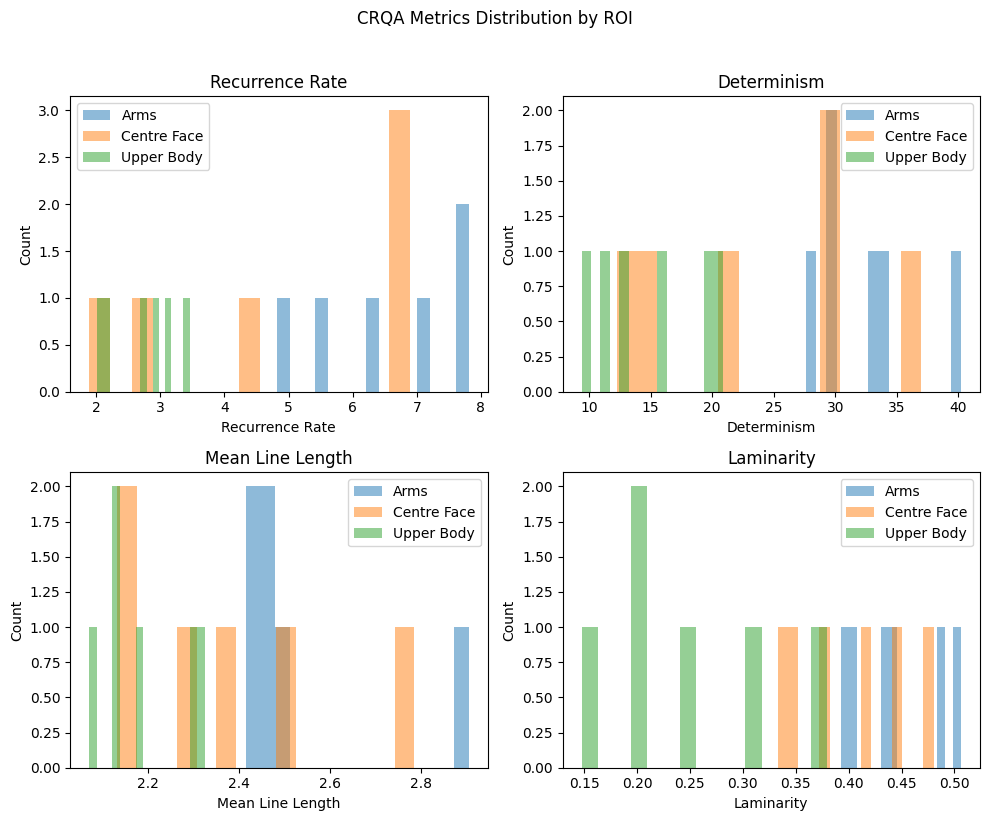

In [91]:
# Load and combine all CRQA analyses
rqa_root = ROOT / "artifacts" / "rqa" / "mosaic"
records = []

for stats_path in sorted(rqa_root.glob("*/rqa_stats.parquet")):
    analysis = stats_path.parent.name
    df_rqa = pd.read_parquet(stats_path)
    if df_rqa.empty:
        continue
    df_rqa["roi"] = analysis.replace("crqa_", "")
    records.append(df_rqa)

if not records:
    print("No CRQA stats found. Run `python run.py rqa --force-rqa` first.")
    wide_rqa_df = pd.DataFrame()
else:
    rqa_df = pd.concat(records, ignore_index=True)
    
    # Parse session/condition info
    rqa_df["session"] = rqa_df["trial_id"].str.extract(r"(S\d+_T\d+)")
    rqa_df["participant"] = rqa_df["trial_id"].str.extract(r"(S\d+)")
    rqa_df["task"] = rqa_df["trial_id"].str.extract(r"S\d+_(T\d+)")
    
    print(f"Loaded CRQA stats: {len(rqa_df)} rows")
    print(f"ROIs: {rqa_df['roi'].unique().tolist()}")
    print(f"Sessions: {rqa_df['session'].unique().tolist()}")
    print(f"Columns: {rqa_df.columns.tolist()}")
    
    # Plot key metrics by ROI (using actual column names from C++ backend)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    # Map display names to actual column names
    metric_map = {
        "Recurrence Rate": "perc_recur",
        "Determinism": "perc_determ", 
        "Mean Line Length": "mean_line_length",
        "Laminarity": "laminarity"
    }
    
    for ax, (display_name, col_name) in zip(axes.flat, metric_map.items()):
        if col_name in rqa_df.columns:
            for roi in rqa_df["roi"].unique():
                roi_data = rqa_df[rqa_df["roi"] == roi][col_name].dropna()
                ax.hist(roi_data, bins=15, alpha=0.5, label=roi.replace("_", " ").title())
            ax.set_xlabel(display_name)
            ax.set_ylabel("Count")
            ax.legend()
            ax.set_title(display_name)
    
    plt.suptitle("CRQA Metrics Distribution by ROI", y=1.02)
    plt.tight_layout()
    plt.show()

### Summary Statistics

In [92]:
# Summary statistics for CRQA metrics by ROI
if records:
    # Use actual column names from RQA C++ backend
    metrics = ["perc_recur", "perc_determ", "mean_line_length", "laminarity", "entropy", "trapping_time"]
    metric_labels = {
        "perc_recur": "Recurrence Rate (%)",
        "perc_determ": "Determinism (%)",
        "mean_line_length": "Mean Line Length",
        "laminarity": "Laminarity",
        "entropy": "Entropy",
        "trapping_time": "Trapping Time"
    }
    available_metrics = [m for m in metrics if m in rqa_df.columns]
    
    print("=== CRQA Summary Statistics by ROI ===\n")
    for roi in rqa_df["roi"].unique():
        print(f"\n{roi.upper().replace('_', ' ')}:")
        roi_data = rqa_df[rqa_df["roi"] == roi]
        for metric in available_metrics:
            mean_val = roi_data[metric].mean()
            std_val = roi_data[metric].std()
            label = metric_labels.get(metric, metric)
            print(f"  {label}: {mean_val:.4f} ± {std_val:.4f}")
else:
    print("No CRQA data available.")

=== CRQA Summary Statistics by ROI ===


ARMS:
  Recurrence Rate (%): 6.5206 ± 1.2008
  Determinism (%): 32.2514 ± 4.5216
  Mean Line Length: 2.5280 ± 0.1865
  Laminarity: 0.4455 ± 0.0437
  Entropy: 1.3710 ± 0.2278
  Trapping Time: 3.0341 ± 0.3759

CENTRE FACE:
  Recurrence Rate (%): 4.8664 ± 2.2255
  Determinism (%): 24.2998 ± 9.9129
  Mean Line Length: 2.3712 ± 0.2454
  Laminarity: 0.3989 ± 0.0568
  Entropy: 1.0658 ± 0.4174
  Trapping Time: 2.9173 ± 0.4225

UPPER BODY:
  Recurrence Rate (%): 2.7320 ± 0.5633
  Determinism (%): 14.9242 ± 4.6674
  Mean Line Length: 2.1891 ± 0.1040
  Laminarity: 0.2466 ± 0.0838
  Entropy: 0.7187 ± 0.2693
  Trapping Time: 2.4077 ± 0.3120
